Install dependencies


In [6]:
import os

# Keep TensorFlow using legacy Keras API for notebook model code
os.environ["TF_USE_LEGACY_KERAS"] = "1"


In [7]:
!pip install -U "tf-nightly[and-cuda]" tf-keras-nightly insightface onnxruntime-gpu opencv-python


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of tf-keras-nightly to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of tf-keras-nightly to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached cython-3.2.4-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_

Download data and uncompress

In [8]:
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
!wget https://www.dropbox.com/s/zcwlujrtz3izcw8/gender.tgz
!tar xvzf gender.tgz

--2026-03-09 17:12:08--  https://www.dropbox.com/s/zcwlujrtz3izcw8/gender.tgz
S'està resolent www.dropbox.com (www.dropbox.com)… 162.125.68.18, 2620:100:6024:18::a27d:4412
S'està connectant a www.dropbox.com (www.dropbox.com)|162.125.68.18|:443… conectat.
HTTP: s'ha enviat la petició, s'està esperant una resposta… 302 Found
Ubicació: https://www.dropbox.com/scl/fi/no7t58h96bzz5x7ypade4/gender.tgz?rlkey=aa02amodss63ee3j09126icpc [es segueix]
--2026-03-09 17:12:09--  https://www.dropbox.com/scl/fi/no7t58h96bzz5x7ypade4/gender.tgz?rlkey=aa02amodss63ee3j09126icpc
S'està reutilitzant la connexió a www.dropbox.com:443.
HTTP: s'ha enviat la petició, s'està esperant una resposta… 302 Found
Ubicació: https://uc1b1bd514143aeafbccfa806a59.dl.dropboxusercontent.com/cd/0/inline/C8WkHmHjJ2pM8od255zQrMME7ufw33mwG2ObrJEkbLAGbGs3_JrSs63FKpp07SD08i_kxT5H7fQuhGhBW1-oUe6J6wIoWKp_q36FNgpvtoNBkNcZXJsA1Z98HvFyw9FFS44/file# [es segueix]
--2026-03-09 17:12:09--  https://uc1b1bd514143aeafbccfa806a59.dl.dropboxu

Import packages


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization as BN
from keras.layers import GaussianNoise as GN
from keras.optimizers import SGD
from keras.callbacks import LearningRateScheduler as LRS
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from insightface.app import FaceAnalysis
import cv2
from pathlib import Path


(10585, 100, 100, 3)
(10585,)
2381
8204
0.2249
(2648, 100, 100, 3)
(2648,)
596
2052
0.2251


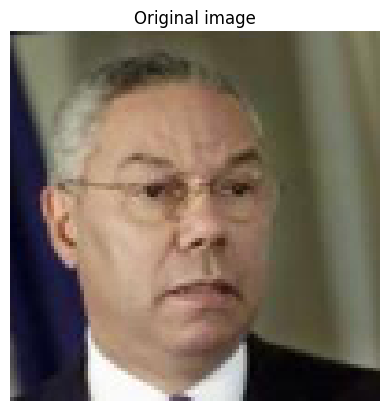

In [35]:
# Load
x_train = np.load('x_train.npy')
x_test = np.load('x_test.npy')

y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

# Stats
print(x_train.shape)
print(y_train.shape)
print(sum(y_train == 1))
print(sum(y_train == 0))
print("{:.4f}".format(sum(y_train == 1)/y_train.shape[0]))
print(x_test.shape)
print(y_test.shape)
print(sum(y_test == 1))
print(sum(y_test == 0))
print("{:.4f}".format(sum(y_test == 1)/y_test.shape[0]))

# View one original sample
plt.imshow(x_train[0])
plt.title('Original image')
plt.axis('off')
plt.show()

Face detection with ArcFace (InsightFace) and square resize


In [46]:
face_app = FaceAnalysis(name="buffalo_l", providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
face_app.prepare(ctx_id=0, det_size=(320, 320))

# Tight crop controls (reduce background around face)
FACE_BOX_SCALE = 0.70
FACE_BOX_Y_SHIFT = 0.05

def center_square_resize(image, target_size=(100, 100)):
    h, w = image.shape[:2]
    side = min(h, w)
    y1 = (h - side) // 2
    x1 = (w - side) // 2
    crop = image[y1:y1 + side, x1:x1 + side]
    return cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)


def square_bbox_from_bbox(image_shape, bbox, scale=1.0, y_shift=0.0):
    h, w = image_shape[:2]
    x1, y1, x2, y2 = bbox

    side = int(round(max(x2 - x1, y2 - y1) * scale))
    if side <= 0:
        return None

    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0 + y_shift * side

    sx1 = int(round(cx - side / 2.0))
    sy1 = int(round(cy - side / 2.0))
    sx2 = sx1 + side
    sy2 = sy1 + side

    if sx1 < 0:
        sx2 -= sx1
        sx1 = 0
    if sy1 < 0:
        sy2 -= sy1
        sy1 = 0
    if sx2 > w:
        shift = sx2 - w
        sx1 = max(0, sx1 - shift)
        sx2 = w
    if sy2 > h:
        shift = sy2 - h
        sy1 = max(0, sy1 - shift)
        sy2 = h

    side2 = min(sx2 - sx1, sy2 - sy1)
    if side2 <= 0:
        return None

    sx2 = sx1 + side2
    sy2 = sy1 + side2
    return int(sx1), int(sy1), int(sx2), int(sy2)


def extract_best_face_bbox(image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    try:
        faces = face_app.get(image_bgr)
    except Exception:
        return None

    if not faces:
        return None

    best_face = max(faces, key=lambda f: float(getattr(f, "det_score", 0.0)))
    x1, y1, x2, y2 = best_face.bbox.astype(int).tolist()

    h, w = image_rgb.shape[:2]
    x1 = int(np.clip(x1, 0, w - 1))
    y1 = int(np.clip(y1, 0, h - 1))
    x2 = int(np.clip(x2, x1 + 1, w))
    y2 = int(np.clip(y2, y1 + 1, h))

    if x2 <= x1 or y2 <= y1:
        return None

    return square_bbox_from_bbox(image_rgb.shape, (x1, y1, x2, y2), scale=FACE_BOX_SCALE, y_shift=FACE_BOX_Y_SHIFT)


def crop_square_from_bbox(image, bbox, target_size=(100, 100)):
    x1, y1, x2, y2 = bbox
    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return cv2.resize(crop, target_size, interpolation=cv2.INTER_AREA)


def preprocess_faces_arcface(images, target_size=(100, 100), dataset_name="dataset"):
    processed = np.empty((images.shape[0], target_size[1], target_size[0], 3), dtype=np.uint8)
    detected_faces = 0

    for idx, image in enumerate(images):
        bbox = extract_best_face_bbox(image)
        if bbox is None:
            raise ValueError(f"{dataset_name}: no face detected at index {idx}. Strict mode forbids full-image fallback.")

        face_crop = crop_square_from_bbox(image, bbox, target_size=target_size)
        if face_crop is None:
            raise ValueError(f"{dataset_name}: invalid face crop at index {idx}.")

        processed[idx] = face_crop
        detected_faces += 1

        if (idx + 1) % 500 == 0:
            print(f"{dataset_name}: {idx + 1}/{images.shape[0]} images processed")

    print(f"{dataset_name}: detected faces in {detected_faces}/{images.shape[0]} images ({detected_faces / images.shape[0]:.2%})")
    return processed


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/odra/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w

ArcFace bbox: (16, 26, 73, 83)


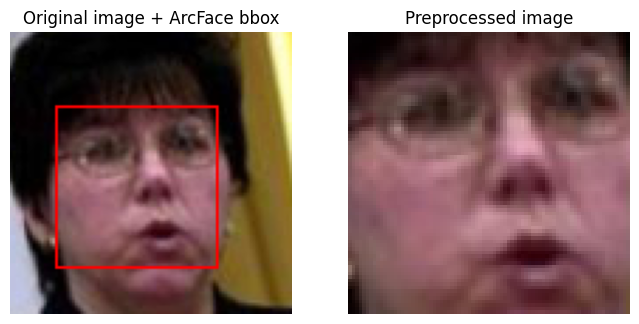

In [79]:
img = x_train[np.random.choice(x_train.shape[0])]

bbox = extract_best_face_bbox(img)
print("ArcFace bbox:", bbox)

if bbox is None:
    raise ValueError('No face detected in sample image. No full-image fallback is allowed.')

img_with_box = img.copy()
x1, y1, x2, y2 = bbox
cv2.rectangle(img_with_box, (x1, y1), (x2, y2), (255, 0, 0), 1)
img_2 = crop_square_from_bbox(img, bbox, target_size=(80, 80))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_with_box)
plt.title("Original image + ArcFace bbox")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(img_2)
plt.title("Preprocessed image")
plt.axis("off")
plt.show()


Load and prepare data

(10585, 100, 100, 3)
(10585,)
2381
8204
0.2249
(2648, 100, 100, 3)
(2648,)
596
2052
0.2251


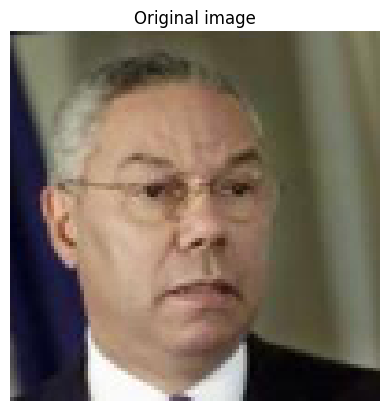

E0000 00:00:1773076203.902503   23465 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773076203.902856   26254 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773076203.923585   23465 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


train: 500/10585 images processed
train: 1000/10585 images processed
train: 1500/10585 images processed
train: 2000/10585 images processed
train: 2500/10585 images processed
train: 3000/10585 images processed
train: 3500/10585 images processed


KeyboardInterrupt: 

In [ ]:
# ArcFace detection + square crop + resize
# Note: this step can take several minutes on CPU for the full dataset.
x_train = preprocess_faces_arcface(x_train, target_size=(100, 100), dataset_name="train")
x_test = preprocess_faces_arcface(x_test, target_size=(100, 100), dataset_name="test")

# View one preprocessed sample
plt.imshow(x_train[0])
plt.title("ArcFace + square resize")
plt.axis("off")
plt.show()

# Transforms
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

x_train /= 255
x_test /= 255

print(x_train.shape)
print(x_test.shape)

num_classes = 2

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


Create model, data augmentation etc... 